In [1]:
import numpy as np
from numpy.typing import NDArray
from warnings import warn, catch_warnings
from collections import Counter, defaultdict
from IPython.core.debugger import set_trace
from random import sample
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.patches as patches

In [2]:
def SuppressWarning(func):
    def wrapper(*args):
        with catch_warnings(action='ignore'):
            func(*args)
    return wrapper

### Basic Player
Implents K-Nearest Neighbors

Player:
* Has a policy, either null or complete
* Complete policies can be polled - get 20/100 random samples from policy, for example.
* Incomplete policies can be made complete via a "learning algorithm"
* All players can see "the world", as polling a complete policy is providing groudning examples to a new generation.
* Initial player (P0) has a "perfect" policy
* P1 polls P0, and then learns a policy from the one-shot polling.
* P0 is retired, P2 is created, and P1 is polled.

In [50]:
class Player:
    def __init__(self, policy: NDArray = None, n_signals: int = 2, n_states: int = 100):
        self.policy = policy
        self.signals = n_signals
        self.states = n_states
        self.given_examples = None

    def poll(self, n_samples: int = -1):
        # randomly polls policy across all "certain" states
        assert self.policy is not None

        # iron out how many samples to take
        if n_samples == -1:
            # try to take 20%
            n_samples = len(self.policy) // 5
            # if 20% can't possible sample each bucket, try.
            if n_samples < self.signals:
                n_samples = self.signals

        valid_moves = []
        groups = defaultdict(list)
        for i in range(self.states):
            group = self.policy[i]
            if group == 0:
                continue
            move = (i, group)
            valid_moves.append(move)
            groups[group].append(move)

        if n_samples > len(valid_moves):
            return valid_moves
        else:
            return sample(valid_moves, n_samples)

    
    def learn(self, examples, k_neighbors):
        # learns policy from examples
        # ideally, we extend Player and override this method 
        # for each learning algorithm we want to implement
        if self.policy is not None:
            warn("This player already has a policy! Be aware, this will overwrite it.")

        # do the learning
        working_policy = np.zeros(self.states, dtype=np.int64)
        n_examples = len(examples)
        for state in range(self.states):
            k_neighbors = k_neighbors if n_examples > k_neighbors else n_examples
            working_policy[state] = self.predict(examples, state, k_neighbors)

        self.policy = working_policy
        self.given_examples = examples


    def predict(self, examples, state, k_neighbors=5):
        # I'm going to implement a basic KNN
        distance = []
        for point_group in examples:
            point, group = point_group
            if isinstance(point, np.int64) or isinstance(point, int):
                dist = abs(state-point)
            else:
                # implement distance function for cartesian points
                dist = 0.5
            distance.append((dist, group))
        neighbors = sorted(distance)[:k_neighbors]
        c = Counter()
        for n in neighbors:
            c[n[1]] += 1
        return c.most_common(1)[0][0]
    
    def utility(self, init_policy):
        # compares (self) player's policy to given policy
        # returns utility score as ratio (0-1)
        assert self.policy is not None
        
        score = 0
        for state in range(self.states):
            if self.policy[state] == init_policy[state]:
                score += 1

        return score / self.states
    
    def plot_strategy(self, ax):
        # given an axis, plot our strategy
        assert self.policy is not None

        cmp = colormaps["Pastel1"].colors
        
        for i in range(self.states):
            signal = self.policy[i]
            if signal == 0:
                color = "white"
            else:
                color = cmp[signal-1]
            rect = patches.Rectangle((i, 0), 1, 1, linewidth=1, edgecolor="black", facecolor=color)
            ax.add_patch(rect)

        ax.set_xlim(0, self.states)
        ax.set_ylim(0, 1)
        ax.set_yticks([])

        return ax


### Other Algorithms


In [51]:
class SKLearnPlayer(Player):
    def __init__(self, *args, **kwargs):
        Player.__init__(self, *args, **kwargs)
        self.classifier = None
        self.threshold = 0.5

    def predict(self, model, state: int):
        probabilities = model.predict_proba(np.array([[state]]))
        most_confident = np.argmax(probabilities[0])
        prediction = most_confident + 1
        confidence = probabilities[0, most_confident]
        return prediction, confidence
    
    def graph_preds(self, filename=None):
        assert self.classifier is not None

        predictions = np.zeros((self.states, self.signals))
        for state in range(self.states):
            preds = self.classifier.predict_proba(np.array([[state]]))
            predictions[state] = preds

        # create legend
        labels = [f"Signal {i+1}" for i in range(self.signals)]
        labels.append("Threshold")

        plt.plot(range(1, self.states+1), predictions)
        plt.plot(range(1, self.states+1), [self.threshold] * self.states)
        plt.xlim(1, 100)
        plt.ylim(0, 1)
        plt.xlabel("State")
        plt.ylabel("Confidence")
        plt.legend(labels=labels)
        plt.grid(True)

        if isinstance(filename, str):
            plt.savefig(filename)
        else:
            plt.show()



In [52]:
from sklearn.neural_network import MLPClassifier

class MLPPlayer(SKLearnPlayer):
    @SuppressWarning
    def learn(self, examples, threshold=0.5):
        # train classifier
        clf = MLPClassifier((3,3), max_iter=10000)
        # (state, signal) - (0, 1), (24, 1), (59, 2)
        X = np.asarray([x[0] for x in examples]).reshape(-1, 1)
        y = np.asarray([x[1] for x in examples])
        
        clf.fit(X, y)

        # predict states for new policy
        working_policy = np.zeros(self.states, dtype=np.int64)
        for i in range(self.states):
            pred, prob = self.predict(clf, i)
            if prob >= threshold:
                working_policy[i] = pred
                
        # set policy
        self.policy = working_policy
        self.classifier = clf
        self.threshold = threshold
        self.given_examples = examples

In [53]:
from sklearn.linear_model import LogisticRegression

class LRPlayer(SKLearnPlayer):
    def learn(self, examples, threshold=0.5):
        # Format data
        X = np.asarray([x[0] for x in examples]).reshape(-1, 1)
        y = np.asarray([x[1] for x in examples])

        # train classifier
        clf = LogisticRegression()
        clf.fit(X, y)

        # predict policy
        working_policy = np.zeros(self.states, dtype=np.int64)
        for i in range(self.states):
            pred, prob = self.predict(clf, i)
            if prob >= threshold:
                working_policy[i] = pred

        # set policy
        self.policy = working_policy
        self.classifier = clf
        self.threshold = threshold
        self.given_examples = examples

In [7]:
def show_history(player_stack):
    _, axes = plt.subplots(nrows=len(player_stack)-1, sharex=True)

    for i, player in enumerate(player_stack[:-1]):
        axes[i] = player.plot_strategy(axes[i])
        axes[i].set_ylabel(i)

    plt.xlabel("States")
    plt.show()

In [8]:
def plot_utility(player_stack, policy):
    player_stack = player_stack[:-1]
    utils = [x.utility(policy) for x in player_stack]
    plt.plot(utils)
    plt.xlabel("Generation")
    plt.ylabel("Utility")
    plt.show()

### Games

In [9]:
# constants
generations = 10
inital_policy = np.array([1 if i < 50 else 2 for i in range(100)], dtype=np.int64)

In [10]:
P0 = Player(policy=inital_policy)
P1 = Player()
K_player_stack = [P0, P1]

# learn loop
for gen in range(generations):
    learner = K_player_stack.pop()
    teacher = K_player_stack.pop()

    examples = teacher.poll(40)
    learner.learn(examples, 3)

    next_gen = Player()
    K_player_stack.append(teacher)
    K_player_stack.append(learner)
    K_player_stack.append(next_gen)

    print("Completed generation " + str(gen))

Completed generation 0
Completed generation 1
Completed generation 2
Completed generation 3
Completed generation 4
Completed generation 5
Completed generation 6
Completed generation 7
Completed generation 8
Completed generation 9


In [59]:
P0 = MLPPlayer(policy=inital_policy)
P1 = MLPPlayer()
player_stack = [P0, P1]

# learn loop
for gen in range(generations):
    learner = player_stack.pop()
    teacher = player_stack.pop()

    examples = teacher.poll(40)
    try:
        learner.learn(examples, 0.65)
    except ValueError:
        set_trace()

    next_gen = MLPPlayer()
    player_stack.append(teacher)
    player_stack.append(learner)
    player_stack.append(next_gen)

    print("Completed generation " + str(gen))

Completed generation 0
Completed generation 1
Completed generation 2
Completed generation 3
Completed generation 4
Completed generation 5
Completed generation 6
Completed generation 7
Completed generation 8
Completed generation 9


In [26]:
P0 = LRPlayer(policy=inital_policy)
P1 = LRPlayer()
LR_player_stack = [P0, P1]

# learn loop
for gen in range(generations):
    learner = LR_player_stack.pop()
    teacher = LR_player_stack.pop()

    examples = teacher.poll(40)
    learner.learn(examples, 0.55)

    next_gen = LRPlayer()
    LR_player_stack.append(teacher)
    LR_player_stack.append(learner)
    LR_player_stack.append(next_gen)

    print("Completed generation " + str(gen))

Completed generation 0
Completed generation 1
Completed generation 2
Completed generation 3
Completed generation 4
Completed generation 5
Completed generation 6
Completed generation 7
Completed generation 8
Completed generation 9


### Printing results

* KNN Player

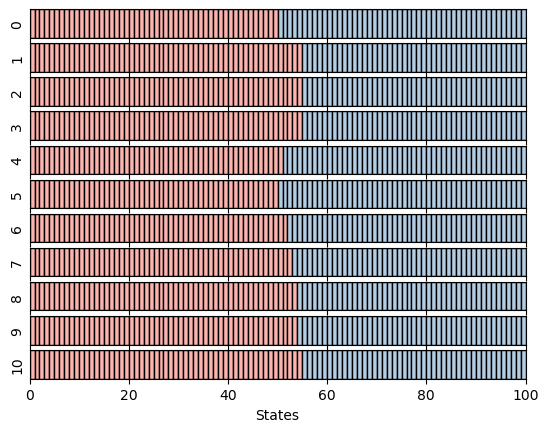

In [13]:
show_history(K_player_stack)

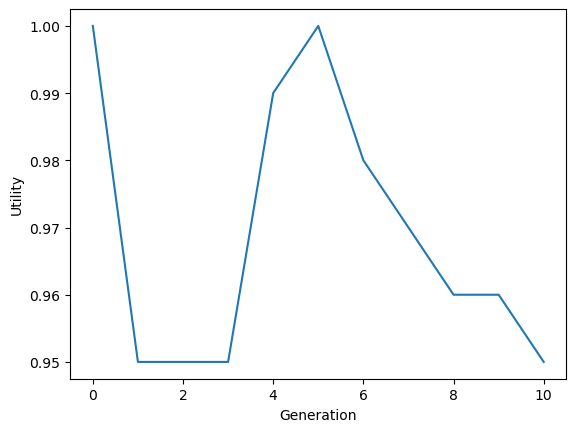

In [14]:
plot_utility(K_player_stack, inital_policy)

* MLP PLayer

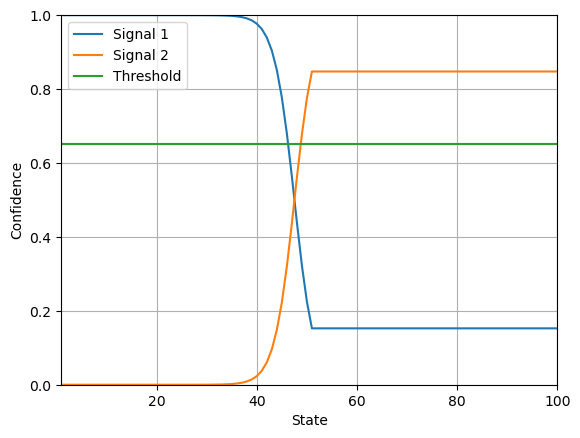

In [60]:
player_stack[1].graph_preds()

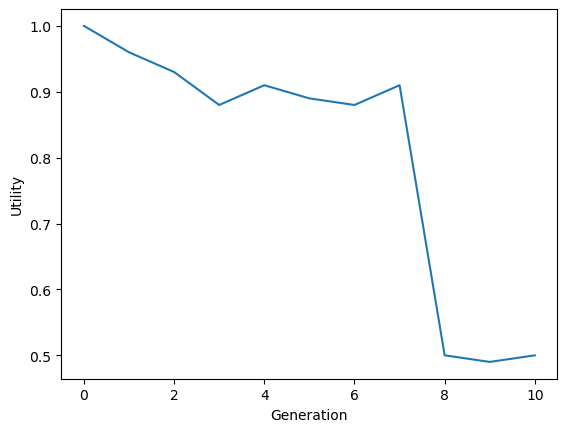

In [61]:
plot_utility(player_stack, inital_policy)

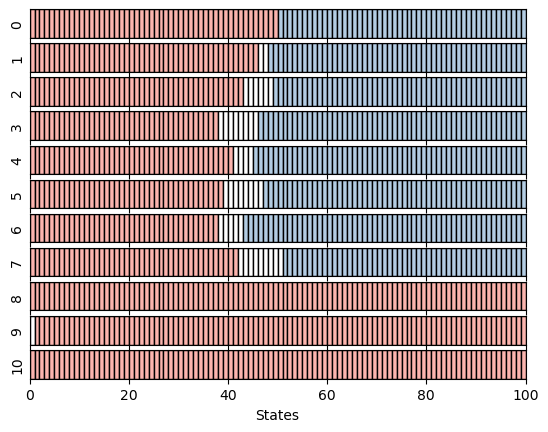

In [62]:
show_history(player_stack)

* Do any non-continuous group structures emerge over time? - Rose?
* can our threshold change over generations? (incr. over time) - Rose?

* Can we implement a player that uses logistic regression? - Max
* Are there any other learning algorithms that are applicable here? - Both

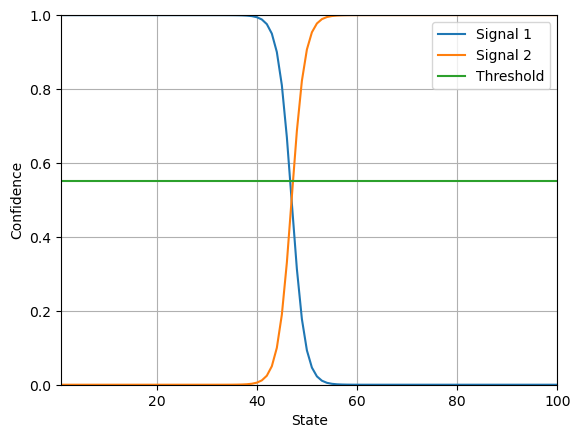

In [30]:
LR_player_stack[1].graph_preds()

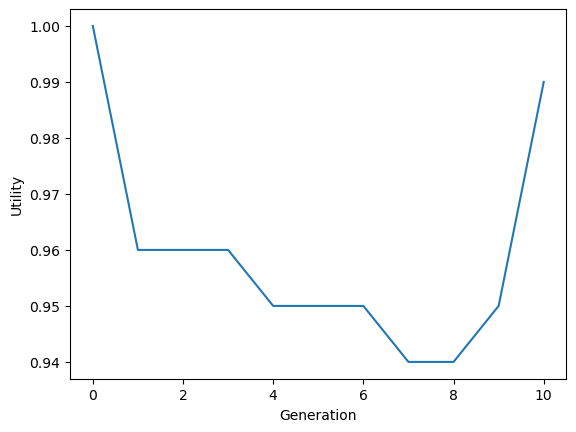

In [27]:
plot_utility(LR_player_stack, inital_policy)

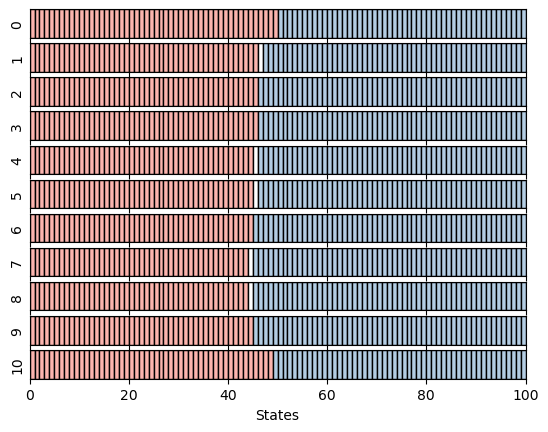

In [31]:
show_history(LR_player_stack)